In [118]:
import pandas as pd
from numpy.ma.extras import median
from pandas.core.array_algos.masked_reductions import mean

orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [119]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [120]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [121]:
delivered = orders[orders['order_status'] == "delivered"].copy()
delivered = delivered.dropna(subset = ["order_delivered_customer_date"])

In [122]:
print(orders.shape)
print(delivered.shape)

(99441, 8)
(96470, 8)


In [123]:
delivered['order_purchase_timestamp'] = pd.to_datetime(delivered['order_purchase_timestamp'])
delivered['order_delivered_customer_date'] = pd.to_datetime(delivered['order_delivered_customer_date'])

delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']
).dt.days

In [124]:
delivered['delivery_days'].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [125]:
print(f"Доставка 0 днів:", (delivered['delivery_days'] <= 0).sum())
delivered[delivered['delivery_days'] <= 0]

Доставка 0 днів: 13


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days
395,38c1e3d4ed6a13cd0cf612d4c09766e9,18c934f4cdc994cd04eb13bce3f47a18,delivered,2018-02-02 15:26:38,2018-02-02 16:00:16,2018-02-03 01:18:26,2018-02-03 15:05:56,2018-02-20 00:00:00,0
735,d3ca7b82c922817b06e5ca21165c5ea2,d23df2c6c3e51d875f458d123b2b3c90,delivered,2017-11-16 13:54:08,2017-11-16 14:08:23,2017-11-16 20:56:53,2017-11-17 13:49:40,2017-11-29 00:00:00,0
31522,1d893dd7ca5f77ebf5f59f0d2017eee0,b19da0df0271e8a3553e3670f86aeab5,delivered,2017-06-19 08:19:45,2017-06-19 08:30:20,2017-06-19 13:32:04,2017-06-19 21:07:52,2017-06-30 00:00:00,0
37753,21a8ffca665bc7a1087d31751a7b7cbc,225aed9e773953084b09cf496c2be05a,delivered,2017-05-31 12:00:35,2017-05-31 13:07:28,2017-05-31 12:43:47,2017-06-01 10:28:24,2017-06-13 00:00:00,0
38792,f3c6775ba3d2d9fe2826f93b71f12008,6aef84c09844a371d82a49152c550b95,delivered,2017-07-04 11:37:47,2017-07-04 11:50:21,2017-07-04 13:53:13,2017-07-05 08:09:26,2017-07-17 00:00:00,0
41803,434cecee7d1a65fc65358a632b6f725f,922a46283625e9c096bfd998913c470c,delivered,2017-05-29 13:21:46,2017-05-29 13:30:24,2017-05-29 14:54:51,2017-05-30 08:06:56,2017-06-19 00:00:00,0
48767,f349cdb62f69c3fae5c4d7d3f3a4a185,c5e200d485ae35a7036cc2e7c1d8ea81,delivered,2018-06-28 14:34:48,2018-06-28 14:50:48,2018-06-28 18:08:00,2018-06-29 14:12:18,2018-07-12 00:00:00,0
48878,d5fbeedc85190ba88580d6f82d1d5ed3,344423c2e26d47d2b6d3dd363a89e812,delivered,2017-05-15 11:50:53,2017-05-15 12:12:07,2017-05-15 12:52:34,2017-05-16 10:21:52,2017-05-24 00:00:00,0
51067,e65f1eeee1f52024ad1dcd03447f7482,198f511b5a75bf936a96f1d4769e3974,delivered,2018-05-18 15:03:19,2018-05-18 15:15:37,2018-05-18 15:00:00,2018-05-19 12:28:30,2018-05-29 00:00:00,0
69291,79e324907160caea526fd8b94389dbbc,331d79b67223ee7e5cd31d3e03e4cfcc,delivered,2018-06-18 12:59:42,2018-06-18 13:16:46,2018-06-18 14:52:00,2018-06-19 12:43:27,2018-06-28 00:00:00,0


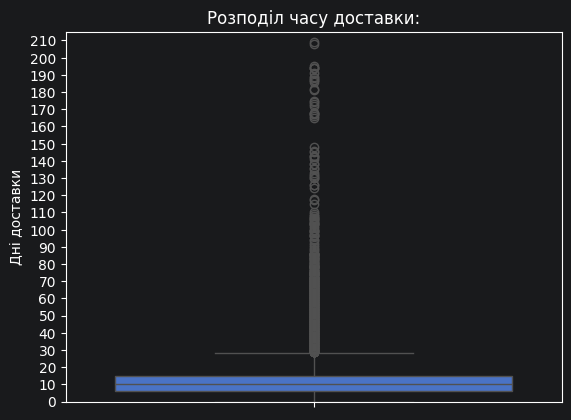

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(delivered['delivery_days'])
plt.ylabel("Дні доставки")
plt.title("Розподіл часу доставки:")
plt.ylim(0, 215)
plt.yticks(range(0, 215, 10))
plt.show()

In [127]:
for threshold in [30, 45, 60, 100]:
    mask = delivered['delivery_days'] >= threshold
    print(f"Частка з >= {threshold} днів: {mask.sum()}, ({mask.mean()*100:.2f})%")


Частка з >= 30 днів: 4550, (4.72)%
Частка з >= 45 днів: 1092, (1.13)%
Частка з >= 60 днів: 306, (0.32)%
Частка з >= 100 днів: 64, (0.07)%


In [128]:
delivered['delivery_days'].quantile([0.5, 0.9, 0.95, 0.99, 0.999, 1.0])

0.500     10.0
0.900     23.0
0.950     29.0
0.990     46.0
0.999     83.0
1.000    209.0
Name: delivery_days, dtype: float64

In [129]:
clean = delivered[(delivered['delivery_days'] < 60) & (delivered['delivery_days'] >= 0)].copy()
clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96164 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96164 non-null  object        
 1   customer_id                    96164 non-null  object        
 2   order_status                   96164 non-null  object        
 3   order_purchase_timestamp       96164 non-null  datetime64[ns]
 4   order_approved_at              96150 non-null  object        
 5   order_delivered_carrier_date   96163 non-null  object        
 6   order_delivered_customer_date  96164 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96164 non-null  object        
 8   delivery_days                  96164 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(6)
memory usage: 7.3+ MB


In [130]:
clean[(clean['delivery_days'] > 60) | (clean['delivery_days'] < 0)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days


In [131]:
clean['purchase_month'] = clean['order_purchase_timestamp'].dt.month
clean['purchase_day_of_week'] = clean['order_purchase_timestamp'].dt.dayofweek

In [132]:
clean.groupby('purchase_month')['delivery_days'].mean()

purchase_month
1     13.135733
2     15.216495
3     14.473451
4     11.635222
5     10.771887
6      9.543639
7      9.431439
8      8.625498
9     11.286680
10    11.717515
11    14.394791
12    14.649663
Name: delivery_days, dtype: float64

In [133]:
clean.groupby('purchase_day_of_week')['delivery_days'].mean()

purchase_day_of_week
0    11.289760
1    11.387103
2    11.695354
3    12.069052
4    12.870216
5    12.660806
6    11.280183
Name: delivery_days, dtype: float64

In [134]:
clean['purchase_year'] = clean['order_purchase_timestamp'].dt.year
clean.groupby('purchase_year')['delivery_days'].agg(['mean', 'count'])

,mean,count
purchase_year,,
2016,18.662879,264
2017,12.267084,43286
2018,11.486372,52614


In [135]:
clean['order_estimated_delivery_date'] = pd.to_datetime(clean['order_estimated_delivery_date'])
clean['estimated_days'] = (
    clean['order_estimated_delivery_date'] - clean['order_purchase_timestamp']
).dt.days
clean[['estimated_days', 'delivery_days']].corr()

,estimated_days,delivery_days
estimated_days,1.00000,0.41955
delivery_days,0.41955,1.00000


In [136]:
clean['estimation_error'] = clean['estimated_days'] - clean['delivery_days']
clean['estimation_error'].describe()

count    96164.000000
mean        11.495861
std          9.227664
min        -50.000000
25%          7.000000
50%         12.000000
75%         16.000000
max        146.000000
Name: estimation_error, dtype: float64

<Axes: ylabel='estimation_error'>

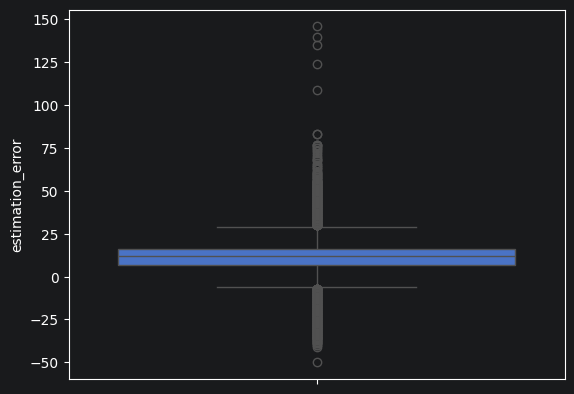

In [137]:
sns.boxplot(clean['estimation_error'])

In [138]:
clean[clean['estimation_error'] >= 100].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,purchase_month,purchase_day_of_week,purchase_year,estimated_days,estimation_error
15791,c72727d29cde4cf870d569bf65edabfd,964253ff0e4e08180064764a450e521f,delivered,2017-02-07 18:01:15,2017-02-09 02:50:07,2017-02-10 05:32:55,2017-02-14 14:27:45,2017-07-04,6,2,1,2017,146,140
40094,0607f0efea4b566f1eb8f7d3c2397320,a5fbb6579eacbeb02752a143bfe82405,delivered,2018-03-06 09:47:07,2018-03-06 09:55:47,2018-03-07 21:33:39,2018-03-09 23:36:47,2018-08-03,3,3,1,2018,149,146
57160,eec7f369423b033e549c02f3c5381205,32cef4bdd6bfa50612d81dc77a93b131,delivered,2018-02-06 20:44:56,2018-02-08 10:10:31,2018-02-15 20:42:12,2018-02-27 16:35:43,2018-07-12,20,2,1,2018,155,135
67488,40dc2ba6f322a17626aac6244332828c,6210a37f9d6a265a4f3fbe2c21672a00,delivered,2017-10-05 21:39:05,2017-10-05 21:49:21,2017-10-09 12:13:58,2017-10-13 13:49:07,2018-01-30,7,10,3,2017,116,109
86444,c2bb89b5c1dd978d507284be78a04cb2,6357fffb5704244d552615bbfcea1442,delivered,2017-05-23 22:28:36,2017-05-24 22:35:08,2017-05-29 02:03:28,2017-06-09 13:35:54,2017-10-11,16,5,1,2017,140,124


In [139]:
print(f"Кількість похибок більших ніж 100 днів:", (clean['estimation_error'] >= 100).sum())

Кількість похибок більших ніж 100 днів: 5


In [140]:
clean[clean['estimation_error'] <= 0].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,purchase_month,purchase_day_of_week,purchase_year,estimated_days,estimation_error
20,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,2017-09-18 14:31:30,2017-09-19 04:04:09,2017-10-06 17:50:03,2017-10-09 22:23:46,2017-09-28,21,9,0,2017,9,-12
25,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,delivered,2018-02-20 23:46:53,2018-02-22 02:30:46,2018-02-26 22:25:22,2018-03-21 22:03:54,2018-03-12,28,2,1,2018,19,-9
35,8563039e855156e48fccee4d611a3196,5f16605299d698660e0606f7eae2d2f9,delivered,2018-02-17 15:59:46,2018-02-17 16:15:34,2018-02-20 23:03:56,2018-03-20 00:59:25,2018-03-20,30,2,5,2018,30,0
41,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,delivered,2017-11-24 21:27:48,2017-11-25 00:21:09,2017-12-13 21:14:05,2017-12-28 18:59:23,2017-12-21,33,11,4,2017,26,-7
57,66e4624ae69e7dc89bd50222b59f581f,684fa6da5134b9e4dab731e00011712d,delivered,2018-03-09 14:50:15,2018-03-09 15:40:39,2018-03-15 00:31:19,2018-04-03 13:28:46,2018-04-02,24,3,4,2018,23,-1


In [141]:
print("Кількість похибок менше ніж 0 днів", (clean['estimation_error'] < 0).sum())

Кількість похибок менше ніж 0 днів 7005


In [142]:
print("MAE оцінка від Olist:", clean['estimation_error'].abs().mean())
print("MAE наївний: ", (clean['delivery_days'] - clean['delivery_days'].mean()).abs().mean().round(2))

MAE оцінка від Olist: 12.670625181980784
MAE наївний:  6.14


Оцінка Olist не на точність, а на уникнення запізнень

In [143]:
print("Кількість рядків: ", len(clean))
print("Унікальних ID: ", clean['order_id'].nunique())

Кількість рядків:  96164
Унікальних ID:  96164


In [144]:
clean['is_weekend'] = (clean['purchase_day_of_week'] >= 5).astype(int)

In [145]:
clean[['purchase_day_of_week', 'is_weekend']]

,purchase_day_of_week,is_weekend
0,0,0
1,1,0
2,2,0
3,5,1
4,1,0
...,...,...
99436,3,0
99437,1,0
99438,6,1
99439,0,0


In [146]:
clean.groupby('is_weekend')['delivery_days'].mean()

is_weekend
0    11.833752
1    11.936974
Name: delivery_days, dtype: float64

In [147]:
clean = clean.drop(columns='is_weekend')

is_weekend ефекту нема

In [148]:
clean['purchase_hour'] = clean['order_purchase_timestamp'].dt.hour
clean.groupby('purchase_hour')['delivery_days'].agg(['mean', 'count'])

,mean,count
purchase_hour,,
0,12.379922,2311
1,12.031887,1129
2,11.809717,494
3,11.841699,259
4,11.123153,203
5,11.521978,182
6,11.429175,473
7,11.355109,1194
8,11.512759,2900


In [149]:
clean = clean.drop(columns='purchase_hour')

In [150]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")

In [151]:
customers.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [152]:
customers['customer_city'].value_counts().head(20)

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
niteroi                    849
santo andre                797
osasco                     746
santos                     713
goiania                    692
sao jose dos campos        691
fortaleza                  654
sorocaba                   633
recife                     613
florianopolis              570
Name: count, dtype: int64

In [153]:
clean = clean.merge(customers[['customer_id', 'customer_state']], on = 'customer_id', how='left')
print(clean.shape)

(96164, 15)


In [154]:
clean.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,purchase_month,purchase_day_of_week,purchase_year,estimated_days,estimation_error,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,10,0,2017,15,7,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,7,1,2018,19,6,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,8,2,2018,26,17,GO


In [155]:
clean.groupby('customer_state')['delivery_days'].agg(['mean', 'count']).sort_values('mean')

,mean,count
customer_state,,
SP,8.190851,40440
PR,11.449054,4917
MG,11.470510,11343
DF,12.459577,2078
RJ,14.358606,12253
SC,14.366949,3540
RS,14.675291,5334
ES,14.886707,1986
GO,14.921147,1953


In [156]:
items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [157]:
items_agg = items.groupby('order_id').agg(
    total_price = ('price', 'sum'),
    total_freight = ('freight_value', 'sum'),
    quantity_items = ('order_item_id', 'count'),
    n_sellers = ('seller_id', 'nunique')
).reset_index()

In [158]:
print(items_agg.shape)

(98666, 5)


In [159]:
clean = clean.merge(items_agg, on='order_id', how='left')

In [160]:
clean.info()
clean.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96164 entries, 0 to 96163
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96164 non-null  object        
 1   customer_id                    96164 non-null  object        
 2   order_status                   96164 non-null  object        
 3   order_purchase_timestamp       96164 non-null  datetime64[ns]
 4   order_approved_at              96150 non-null  object        
 5   order_delivered_carrier_date   96163 non-null  object        
 6   order_delivered_customer_date  96164 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96164 non-null  datetime64[ns]
 8   delivery_days                  96164 non-null  int64         
 9   purchase_month                 96164 non-null  int32         
 10  purchase_day_of_week           96164 non-null  int32         
 11  purchase_year  

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,purchase_month,purchase_day_of_week,purchase_year,estimated_days,estimation_error,customer_state,total_price,total_freight,quantity_items,n_sellers
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,10,0,2017,15,7,SP,29.99,8.72,1,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,7,1,2018,19,6,BA,118.70,22.76,1,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,8,2,2018,26,17,GO,159.90,19.22,1,1


In [161]:
clean['n_sellers'].value_counts()

n_sellers
1    94889
2     1216
3       54
4        3
5        2
Name: count, dtype: int64

Для seller_state беру першого продавця замовлення. 98.7% замовлень мають одного продавця.

In [162]:
first_seller = items.sort_values('order_item_id').drop_duplicates('order_id')[['order_id', 'seller_id', 'product_id']]
clean = clean.merge(first_seller, on='order_id', how='left')

In [163]:
sellers = pd.read_csv('../data/raw/olist_sellers_dataset.csv')
clean = clean.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
print(clean.shape)

(96164, 22)


In [164]:
clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96164 entries, 0 to 96163
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96164 non-null  object        
 1   customer_id                    96164 non-null  object        
 2   order_status                   96164 non-null  object        
 3   order_purchase_timestamp       96164 non-null  datetime64[ns]
 4   order_approved_at              96150 non-null  object        
 5   order_delivered_carrier_date   96163 non-null  object        
 6   order_delivered_customer_date  96164 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96164 non-null  datetime64[ns]
 8   delivery_days                  96164 non-null  int64         
 9   purchase_month                 96164 non-null  int32         
 10  purchase_day_of_week           96164 non-null  int32         
 11  purchase_year  

In [165]:
clean.groupby('customer_state')['delivery_days'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False).round(2)

,mean,median,count
customer_state,,,
AM,25.21,25.0,144
AP,24.30,24.0,66
AL,23.64,22.0,394
RR,22.95,23.5,38
PA,22.56,20.5,934
MA,20.66,19.0,712
SE,19.84,17.0,332
CE,19.72,18.0,1257
PB,19.42,18.0,512


In [166]:
clean['same_state'] = (clean['customer_state'] == clean['seller_state']).astype(int)
clean.groupby('same_state')['delivery_days'].agg(['mean', 'count']).round(2)

,mean,count
same_state,,
0,14.38,61506
1,7.38,34658


In [167]:
sp = clean[clean['customer_state'] == 'SP']
sp.groupby('same_state')['delivery_days'].agg(['mean', 'count']).round(2)

,mean,count
same_state,,
0,10.73,9743
1,7.38,30697


перевірка чи має вплив SP 14.38 vs 7.38. Але 88.6% групи same_state=1 це SP. Всередині SP різниця падає до 3.35 дня

In [168]:
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
products.info()
products.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [169]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [170]:
print(products['product_id'].is_unique)

True


In [171]:
products_cols = ["product_id",'product_category_name', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

clean = clean.merge(products[products_cols], on = 'product_id', how='left')

In [172]:
clean.shape

(96164, 28)

In [173]:
for col in ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    clean[col] = clean[col].fillna(clean[col].median())

In [174]:
clean['product_category_name'] = clean['product_category_name'].fillna('unknown')

In [176]:
clean.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
delivery_days                     0
purchase_month                    0
purchase_day_of_week              0
purchase_year                     0
estimated_days                    0
estimation_error                  0
customer_state                    0
total_price                       0
total_freight                     0
quantity_items                    0
n_sellers                         0
seller_id                         0
product_id                        0
seller_state                      0
same_state                        0
product_category_name             0
product_weight_g                  0
product_length_cm                 0
product_height_cm                 0
product_width_cm            

order_approved і order_delivered_carrier в фічі не йдуть

In [178]:
clean['volume_cm3'] = (clean['product_width_cm'] *
                      clean['product_height_cm'] *
                      clean['product_length_cm'])

In [180]:
clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96164 entries, 0 to 96163
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96164 non-null  object        
 1   customer_id                    96164 non-null  object        
 2   order_status                   96164 non-null  object        
 3   order_purchase_timestamp       96164 non-null  datetime64[ns]
 4   order_approved_at              96150 non-null  object        
 5   order_delivered_carrier_date   96163 non-null  object        
 6   order_delivered_customer_date  96164 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96164 non-null  datetime64[ns]
 8   delivery_days                  96164 non-null  int64         
 9   purchase_month                 96164 non-null  int32         
 10  purchase_day_of_week           96164 non-null  int32         
 11  purchase_year  

In [181]:
num_cols = ['delivery_days', 'total_price', 'total_freight', 'quantity_items', 'volume_cm3', 'product_weight_g', 'same_state']
clean[num_cols].corr()['delivery_days'].sort_values(ascending=False).round(3)

delivery_days       1.000
total_freight       0.181
product_weight_g    0.083
volume_cm3          0.072
total_price         0.056
quantity_items     -0.019
same_state         -0.401
Name: delivery_days, dtype: float64